In [2]:
import os

# Crear la carpeta si no existe
if not os.path.exists('archivos'):
    os.makedirs('archivos')
    print("Carpeta 'archivos' creada con éxito.")
else:
    print("La carpeta 'archivos' ya existe.")

#Subir archivos de las señales en formato .txt en esta carpeta para correr el codigo.

La carpeta 'archivos' ya existe.


In [2]:
%pip install endaq pandas matplotlib plotly scipy numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import scipy
import plotly
import endaq

print("¡Librerías instaladas correctamente!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Plotly version: {plotly.__version__}")

c:\Users\Emil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


¡Librerías instaladas correctamente!
Pandas version: 2.2.3
Numpy version: 2.2.4
Scipy version: 1.16.2
Plotly version: 6.6.0


In [4]:
# ==========================================
# SECCIÓN 1: IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import os
import glob
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Librerías de enDAQ
import endaq
import endaq.plot.utilities
import endaq.calc.psd as psd


# ==========================================
# SECCIÓN 2: CARGA Y PREPARACIÓN DE DATOS
# ==========================================
nombre_carpeta = "archivos"  # Cambia esto por el nombre real de tu carpeta
ruta_busqueda = os.path.join(nombre_carpeta, "*.txt")
archivos = sorted(glob.glob(ruta_busqueda))

print(f"Archivos encontrados: {archivos}")

# Lectura y concatenación de archivos
lista_df = []
for f in archivos:
    # Leemos cada archivo (sin cabecera, columnas: tiempo y aceleración)
    temp_df = pd.read_csv(f, sep='\t', header=None, names=['time', 'acceleration'])
    lista_df.append(temp_df)

# Concatenar todos en un solo DataFrame y preparar el índice para enDAQ
df_completo = pd.concat(lista_df, ignore_index=True)
df_completo = df_completo.sort_values('time').set_index('time')

Archivos encontrados: ['archivos\\ts1.txt', 'archivos\\ts2.txt', 'archivos\\ts3.txt', 'archivos\\ts4.txt']


In [ ]:
# ==========================================
# SECCIÓN 3: PARÁMETROS BÁSICOS Y LIMPIEZA
# ==========================================
# Extraer vectores para Scipy
tiempo = df_completo.index.values
aceleracion_cruda = df_completo['acceleration'].values

# Eliminar el DC Offset (Gravedad) restando la media
aceleracion_limpia = aceleracion_cruda - np.mean(aceleracion_cruda)
df_analisis = df_completo - df_completo.mean()

# Calcular Frecuencia de Muestreo (Fs) automáticamente
dt = tiempo[1] - tiempo[0]
fs = int(round(1 / dt))
print(f"Frecuencia de muestreo calculada: {fs} Hz")

print(f"\n--- PARÁMETROS DE LA SEÑAL ---")
print(f"Puntos totales: {len(aceleracion_limpia)}")
print(f"Frecuencia de muestreo (Fs): {fs} Hz")

# Gráfica general rápida de la serie de tiempo con Plotly
fig_raw = px.line(df_completo, title="Serie de Tiempo: Aceleración Original")
fig_raw.update_layout(yaxis_title='Acceleration (g)', xaxis_title='Time (s)')
fig_raw.show()

Frecuencia de muestreo calculada: 1000 Hz

--- PARÁMETROS DE LA SEÑAL ---
Puntos totales: 2400000
Frecuencia de muestreo (Fs): 1000 Hz


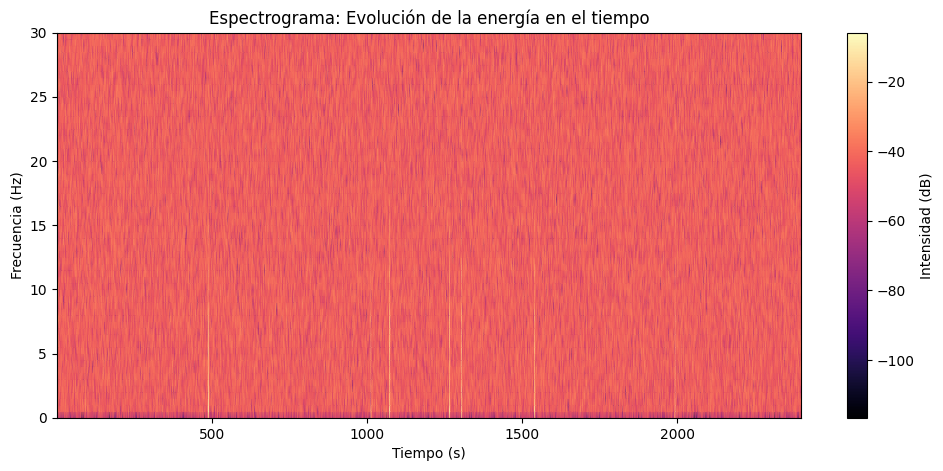

In [ ]:
# ==========================================
# SECCIÓN 4: ESPECTROGRAMA (Evolución temporal)
# ==========================================
# Nos permite ver cómo evoluciona la intensidad de las frecuencias en el tiempo
f, t, Sxx = signal.spectrogram(df_analisis.iloc[:,0].values, fs, nperseg=fs*2)

plt.figure(figsize=(12, 5))
plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
plt.ylim(0, 30)  # Zoom a la zona de interés
plt.colorbar(label='Intensidad (dB)')
plt.ylabel('Frecuencia (Hz)')
plt.xlabel('Tiempo (s)')
plt.title('Espectrograma: Evolución de la energía en el tiempo')
plt.show()

In [ ]:
# ==========================================
# SECCIÓN 5: CÁLCULO DE AMORTIGUAMIENTO (Método 3dB)
# ==========================================
res_fina = 0.05
df_psd_fina = psd.welch(df_analisis, bin_width=res_fina)

# Encontrar el pico máximo en el rango del rociador (5-15 Hz según tu código anterior)
mask_amortiguamiento = (df_psd_fina.index > 5) & (df_psd_fina.index < 15)
segmento = df_psd_fina[mask_amortiguamiento]
f_pico = segmento.idxmax().values[0]
p_pico = segmento.max().values[0]

# Hallar los puntos de media potencia (p_pico / 2)
p_media = p_pico / 2
f_indices = np.where(np.diff(np.sign(df_psd_fina.iloc[:,0] - p_media)))[0]
f_puntos = df_psd_fina.index[f_indices]

# Seleccionamos las dos frecuencias más cercanas al pico
f_izq = f_puntos[f_puntos < f_pico][-1]
f_der = f_puntos[f_puntos > f_pico][0]

fwhm = f_der - f_izq # Ancho de banda
zeta = fwhm / (2 * f_pico) # Razón de amortiguamiento aproximada

print(f"\n--- REPORTE TÉCNICO DEL PICO (Toda la señal) ---")
print(f"Frecuencia Natural: {f_pico:.2f} Hz")
print(f"Ancho de Banda (FWHM): {fwhm:.3f} Hz")
print(f"Razón de Amortiguamiento (zeta): {zeta*100:.2f}%")


--- REPORTE TÉCNICO DEL PICO (Toda la señal) ---
Frecuencia Natural: 5.65 Hz
Ancho de Banda (FWHM): 1.500 Hz
Razón de Amortiguamiento (zeta): 13.27%


In [ ]:
# ==========================================
# SECCIÓN 6: ANÁLISIS AISLADO DEL IMPACTO
# ==========================================
# 6.1 Encontrar el instante exacto del golpe
indice_impacto = np.argmax(np.abs(aceleracion_limpia))
tiempo_impacto = tiempo[indice_impacto]

print(f"\n--- ANÁLISIS DEL IMPACTO ---")
print(f"Impacto detectado en el segundo: {tiempo_impacto:.2f}")

# 6.2 Recortar la señal (1s antes, 4s después)
segundos_antes = 1
segundos_despues = 4
indice_inicio = max(0, indice_impacto - (segundos_antes * fs))
indice_fin = min(len(aceleracion_limpia), indice_impacto + (segundos_despues * fs))

acel_impacto = aceleracion_limpia[indice_inicio:indice_fin]
tiempo_impacto_arr = tiempo[indice_inicio:indice_fin]

print(f"Señal recortada a {len(acel_impacto)/fs:.1f} segundos alrededor del impacto.")

# 6.3 PSD (Welch) sobre el impacto aislado
ventana_segundos = 2
nperseg = fs * ventana_segundos
frecuencias, psd_valores = signal.welch(acel_impacto, fs=fs, nperseg=nperseg)

# 6.4 Identificación de picos (Umbral Estadístico: 2 a 30 Hz)
mask_analisis = (frecuencias >= 2) & (frecuencias <= 30)
f_analisis = frecuencias[mask_analisis]
psd_analisis = psd_valores[mask_analisis]

media_psd = np.mean(psd_analisis)
std_psd = np.std(psd_analisis)
k_sigma = 3
umbral = media_psd + (k_sigma * std_psd)

# Detectar picos separados al menos 1 Hz
indices_picos, _ = signal.find_peaks(psd_analisis, height=umbral, distance=int(1 / (1/ventana_segundos)))
frecuencias_picos = f_analisis[indices_picos]
amplitudes_picos = psd_analisis[indices_picos]

print(f"\n--- RESULTADOS DE PICOS (Rango 2-30 Hz) ---")
print(f"Umbral calculado (Media + 3σ): {umbral:.6f}")
for f_val, a_val in zip(frecuencias_picos, amplitudes_picos):
    print(f"Pico detectado en: {f_val:.2f} Hz con amplitud {a_val:.6f}")


--- ANÁLISIS DEL IMPACTO ---
Impacto detectado en el segundo: 489.22
Señal recortada a 5.0 segundos alrededor del impacto.

--- RESULTADOS DE PICOS (Rango 2-30 Hz) ---
Umbral calculado (Media + 3σ): 0.011654
Pico detectado en: 5.50 Hz con amplitud 0.012949


In [ ]:
# ==========================================
# SECCIÓN 7: VISUALIZACIÓN INTERACTIVA DEL IMPACTO (PLOTLY)
# ==========================================s
fig = go.Figure()

# Curva de la PSD
fig.add_trace(go.Scatter(
    x=f_analisis, y=psd_analisis,
    mode='lines', name='PSD (2-30 Hz)',
    line=dict(color='royalblue', width=2)
))

# Línea del Umbral
fig.add_trace(go.Scatter(
    x=f_analisis, y=[umbral] * len(f_analisis),
    mode='lines', name=f'Umbral ({k_sigma}σ)',
    line=dict(color='red', width=2, dash='dash')
))

# Marcar los picos detectados
fig.add_trace(go.Scatter(
    x=frecuencias_picos, y=amplitudes_picos,
    mode='markers', name='Picos Válidos',
    marker=dict(color='black', size=10, symbol='x')
))

# Resaltar la zona de resonancia (5-10 Hz)
fig.add_vrect(
    x0=5, x1=10,
    fillcolor="MediumPurple", opacity=0.2,
    layer="below", line_width=0,
    annotation_text="Zona de Resonancia",
    annotation_position="top left"
)

fig.update_layout(
    title="Espectro de Potencia (PSD) del Impacto Aislado",
    xaxis_title="Frecuencia (Hz)",
    yaxis_title="Densidad de Potencia (g² / Hz)",
    template="plotly_white",
    hovermode="x unified",
    width=900,
    height=600,
)

fig.update_xaxes(range=[2, 15])
fig.show()

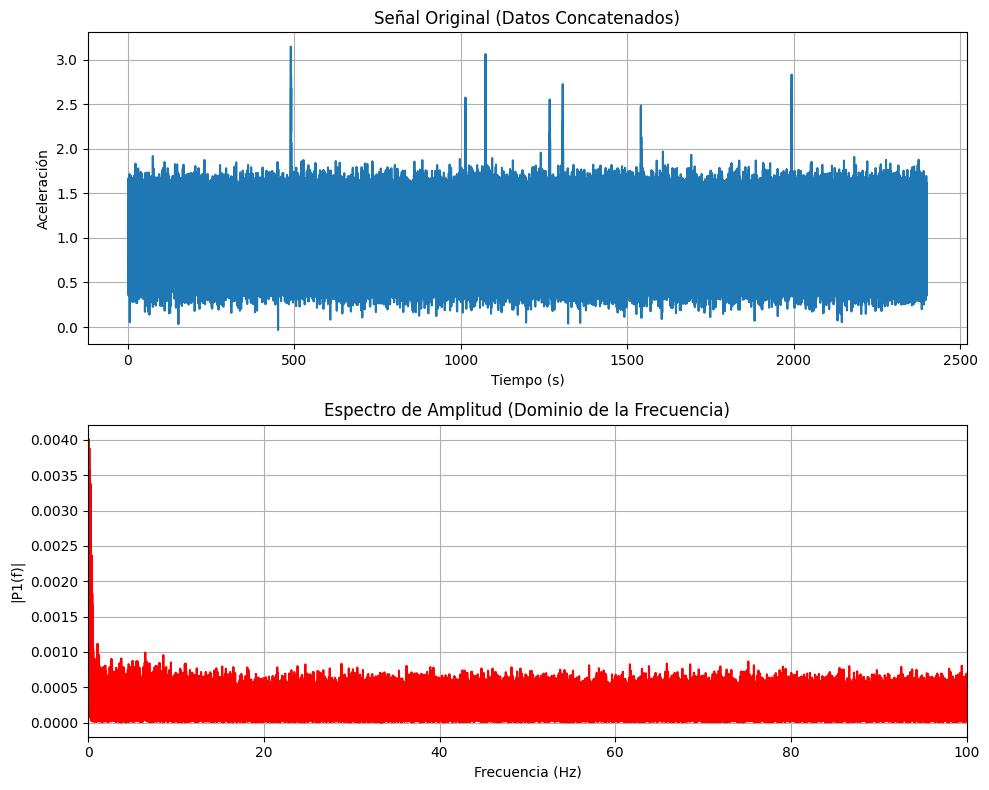

La frecuencia con mayor energía es: 0.05 Hz
La amplitud máxima en esa frecuencia es: 0.0040


In [ ]:
# --- 1. Extraer los datos del DataFrame ya cargado ---
# Usamos los nombres de columnas que definiste en tu bloque anterior ('time', 'acceleration')
tiempo = df_completo.index.values if df_completo.index.name == 'time' else df_completo['time'].values
aceleracion = df_completo['acceleration'].values

# --- 2. Parámetros de la señal ---
L = len(aceleracion)
# Calculamos Fs dinámicamente basándonos en los datos cargados
Fs = 1 / (tiempo[1] - tiempo[0])

# --- 3. Pre-procesamiento ---
# Restamos la media para eliminar el pico en 0 Hz (componente DC/Gravedad)
aceleracion_detrend = aceleracion - np.mean(aceleracion)

# --- 4. Calcular la FFT ---
Y = np.fft.fft(aceleracion_detrend)

# --- 5. Calcular el espectro de amplitud de un solo lado (Single-Sided Spectrum) ---
P2 = np.abs(Y / L)                        # Espectro de dos lados
P1 = P2[:int(L/2) + 1].copy()             # Tomar solo la primera mitad
P1[1:-1] = 2 * P1[1:-1]                   # Multiplicar por 2 para conservar la energía

# --- 6. Definir el eje de frecuencias ---
f = Fs * np.arange(0, (L/2) + 1) / L

# --- 7. Graficar resultados ---
plt.figure(figsize=(10, 8))

# Gráfica en el dominio del Tiempo
plt.subplot(2, 1, 1)
plt.plot(tiempo, aceleracion)
plt.title('Señal Original (Datos Concatenados)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Aceleración')
plt.grid(True)

# Gráfica en el dominio de la Frecuencia (FFT)
plt.subplot(2, 1, 2)
plt.plot(f, P1, 'r', linewidth=1.5)
plt.title('Espectro de Amplitud (Dominio de la Frecuencia)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|P1(f)|')
plt.xlim([0, 100]) # Ajusta según la frecuencia que esperas ver
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 8. Encontrar la frecuencia dominante ---
idx = np.argmax(P1)
max_amp = P1[idx]
print(f'La frecuencia con mayor energía es: {f[idx]:.2f} Hz')
print(f'La amplitud máxima en esa frecuencia es: {max_amp:.4f}')

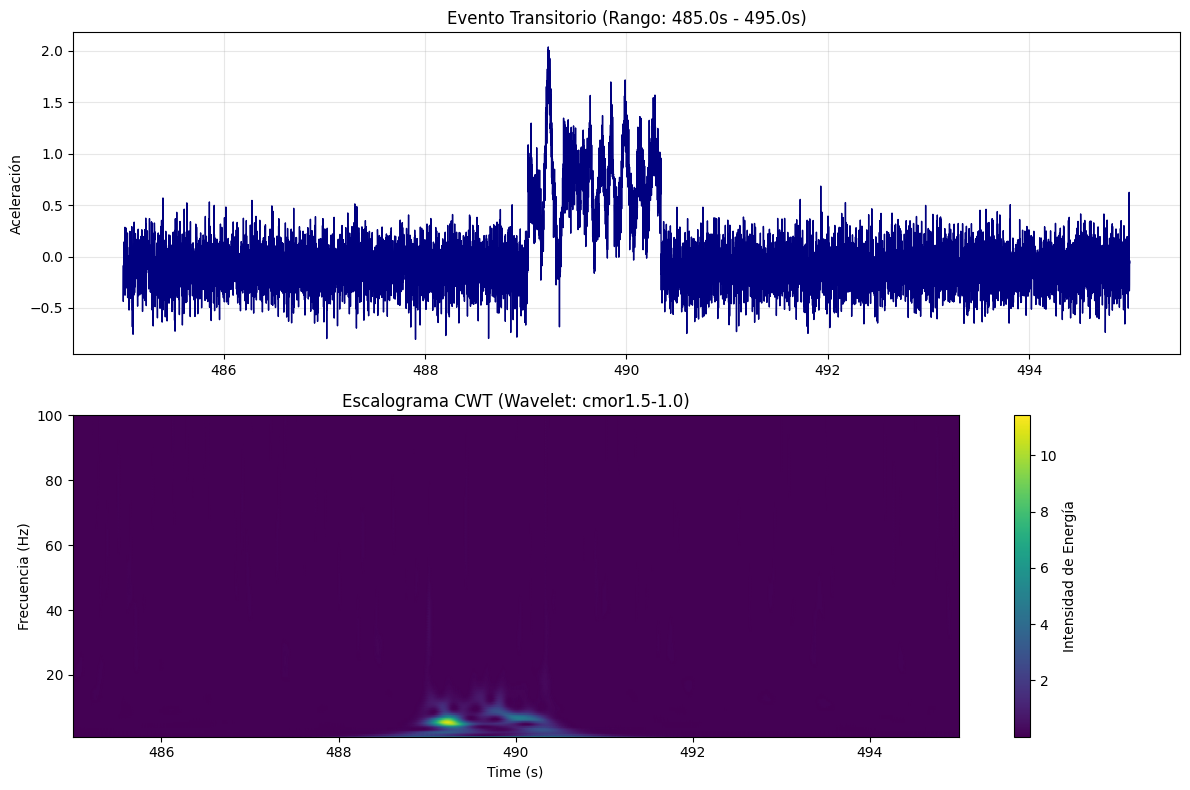

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

## CWT (Continuous Wavelet Transform) ##

# --- 1. Extraer datos del DataFrame ya cargado ---
# Usamos el índice (tiempo) y la columna de aceleración del bloque previo
tiempo = df_completo.index.values if df_completo.index.name == 'time' else df_completo['time'].values
aceleracion = df_completo['acceleration'].values

# Cálculo de Frecuencia de Muestreo (Fs)
Fs = 1 / (tiempo[1] - tiempo[0])

# --- 2. Gate the signal (Ventaneo/Segmentación) ---
# Definimos el rango de tiempo de interés (puedes ajustar t_start y t_end)
t_start, t_end = 485, 495
mask = (tiempo >= t_start) & (tiempo <= t_end)

if not np.any(mask):
    print(f"Advertencia: No se encontraron datos en el rango {t_start}-{t_end}s.")
    # Si no hay datos en ese rango, usamos toda la señal para evitar errores
    t_segment = tiempo
    sig_segment = aceleracion - np.mean(aceleracion)
else:
    t_segment = tiempo[mask]
    sig_segment = aceleracion[mask] - np.mean(aceleracion[mask])

# --- 3. Definir parámetros de CWT ---
wavelet = 'cmor1.5-1.0'
frequencies = np.linspace(1, 100, 200)
# Convertimos las frecuencias deseadas a escalas para el wavelet elegido
scales = pywt.frequency2scale(wavelet, frequencies / Fs)

# --- 4. Ejecutar la Transformada Continua de Wavelet ---
coefficients, freq_axis = pywt.cwt(sig_segment, scales, wavelet, sampling_period=1/Fs)

# --- 5. Calcular Densidad de Energía ---
power = (np.abs(coefficients))**2

# --- 6. Graficar Escalograma ---
plt.figure(figsize=(12, 8))

# Gráfica Superior: Señal en el dominio del tiempo (segmento)
plt.subplot(2, 1, 1)
plt.plot(t_segment, sig_segment, color='navy', lw=1)
plt.title(f'Evento Transitorio (Rango: {t_segment[0]:.1f}s - {t_segment[-1]:.1f}s)')
plt.ylabel('Aceleración')
plt.grid(alpha=0.3)

# Gráfica Inferior: Escalograma CWT
plt.subplot(2, 1, 2)
# Usamos pcolormesh para visualizar la evolución de frecuencias en el tiempo
plt.pcolormesh(t_segment, frequencies, power, shading='gouraud', cmap='viridis')
plt.title(f'Escalograma CWT (Wavelet: {wavelet})')
plt.ylabel('Frecuencia (Hz)')
plt.xlabel('Time (s)')
plt.ylim([1, 100])
plt.colorbar(label='Intensidad de Energía')

plt.tight_layout()
plt.show()